In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn tqdm

In [2]:
import os
import pandas as pd
file_path = 'final_trendingtopics.csv'
if os.path.exists(file_path):
    print(f'File size: {os.path.getsize(file_path)} bytes')
    raw_df = pd.read_csv(file_path)
    print(f'Total rows: {len(raw_df)}')
    display(raw_df.head())
else:
    print('Error: CSV file not found.')

File size: 4725139 bytes
Total rows: 10233


,id,text,created_at,username,likes,retweets,topic,timestamp,text_cleaned,text_translated,detected_lang
0,1960875468531621946,@PsyGuy007 bien vue super les gars...,2025-08-28,JaegerStep78492,0.0,NaN,Super Bowl LX,NaN,bien vue super les gars...,good view great guys...,fr
1,1960973143008292871,"You know what, I've ALSO been a splendid nigga...",2025-08-28,JSRingo,209.0,NaN,Super Bowl LX,NaN,"You know what, I've ALSO been a splendid nigga...","You know what, I've ALSO been a splendid nigga...",en
2,1961159089544990909,@fashion_nfl Don’t think enough people are tal...,2025-08-28,p23rce,479.0,NaN,Super Bowl LX,NaN,Don’t think enough people are talking about th...,Don’t think enough people are talking about th...,en
3,1960932935676387741,RT @tahsin_adib: NINGNING telling winter it mu...,2025-08-28,hidden_faayz,0.0,NaN,Winter Olympics 2026 Milano,NaN,NINGNING telling winter it must've take a long...,NINGNING telling winter it must've take a long...,en
4,1961003661548741029,Super sleepy. https://t.co/FMEc5ShIuv,2025-08-28,FajitaFantom,17.0,NaN,Super Bowl LX,NaN,Super sleepy.,Super sleepy.,af


In [3]:
import pandas as pd
import re
import string
import numpy as np
df = pd.read_csv('final_trendingtopics.csv')
if 'created_at' in df.columns:
    df['timestamp'] = pd.to_datetime(df['created_at'], errors='coerce')
elif 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['text_translated'])
print('Data Loaded.')

Data Loaded.


In [4]:
def advanced_clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df['text_translated_clean'] = df['text_translated'].apply(advanced_clean_text)
print('Advanced Cleaning Complete.')

Advanced Cleaning Complete.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english', max_df=0.7, min_df=5, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(df['text_translated_clean'])
print('TF-IDF Vectorization Complete.')

TF-IDF Vectorization Complete.


In [6]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
print('PCA/SVD Dimensionality Reduction Complete.')

PCA/SVD Dimensionality Reduction Complete.


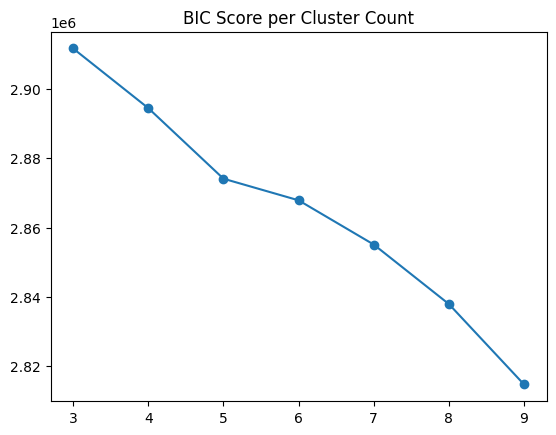

Optimal k identified: 9


In [7]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
bic_scores = []
n_range = range(3, 10)
for n in n_range:
    test_gmm = GaussianMixture(n_components=n, covariance_type='tied', random_state=42)
    test_gmm.fit(X_scaled)
    bic_scores.append(test_gmm.bic(X_scaled))
plt.plot(n_range, bic_scores, marker='o')
plt.title('BIC Score per Cluster Count')
plt.show()
optimal_k = n_range[np.argmin(bic_scores)]
print(f'Optimal k identified: {optimal_k}')

In [8]:
gmm = GaussianMixture(n_components=optimal_k, covariance_type='tied', random_state=42)
df['cluster'] = gmm.fit_predict(X_scaled)
print('GMM Model Fit. Cluster column created.')

GMM Model Fit. Cluster column created.


In [9]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, df['cluster'])
print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.0822


In [10]:
feature_names = vectorizer.get_feature_names_out()
def get_top_words(cluster_indices, X_tfidf, n=10):
    mean_tfidf = X_tfidf[cluster_indices].mean(axis=0)
    sorted_indices = np.argsort(mean_tfidf.A1)[::-1]
    return [feature_names[i] for i in sorted_indices[:n]]
for i in range(optimal_k):
    indices = np.where(df['cluster'] == i)[0]
    print(f'Cluster {i}: {get_top_words(indices, X_tfidf)}')

Cluster 0: ['way', 'super', 'super bowl', 'bowl', 'people', 'winter', 'time', 'like', 'good', 'think']
Cluster 1: ['make', 'super', 'make super', 'bowl', 'super bowl', 'like', 'let', 'let make', 'just', 'year']
Cluster 2: ['super', 'winter', 'year', 'olympics', 'like', 'new', 'just', 'world', 'bowl', 'great']
Cluster 3: ['election', 'trump', 'vote', 'win election', 'win', 'just', 'lost election', 'election integrity', 'won election', 'time']
Cluster 4: ['bowl', 'super bowl', 'super', 'halftime', 'bowl halftime', 'bad', 'bunny', 'bad bunny', 'im', 'nfl']
Cluster 5: ['mario', 'super mario', 'mario galaxy', 'galaxy', 'super', 'galaxy movie', 'movie', 'mario bros', 'bros', 'nintendo']
Cluster 6: ['cool', 'super cool', 'super', 'man', 'super duper', 'duper', 'looks super', 'love', 'looks', 'look']
Cluster 7: ['february', 'th', 'february th', 'today', 'th february', 'day', 'amp', 'wednesday', 'nd', 'date']
Cluster 8: ['bullish', 'super bullish', 'super', 'project', 'im super', 'future', 'im'

/tmp/ipykernel_49358/2382957982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cluster', palette='viridis', ax=ax[0])


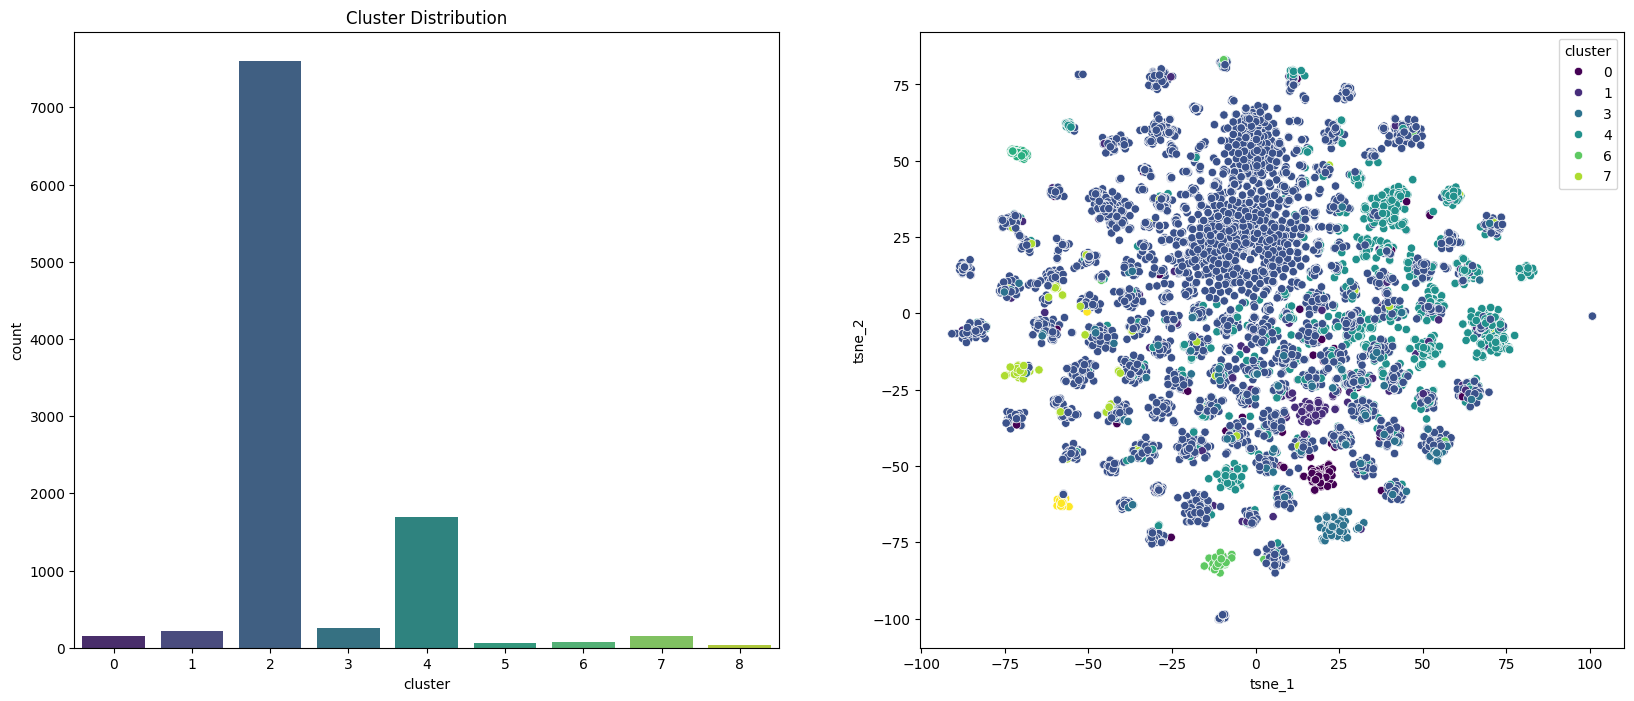

In [11]:
import seaborn as sns
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
sns.countplot(data=df, x='cluster', palette='viridis', ax=ax[0])
ax[0].set_title('Cluster Distribution')
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['cluster'] = df['cluster'].values
sns.scatterplot(x='tsne_1', y='tsne_2', hue='cluster', palette='viridis', data=df_tsne, ax=ax[1])
plt.show()

In [13]:
df_filtered = df.dropna(subset=['timestamp']).copy()
df_filtered['date'] = df_filtered['timestamp'].dt.date
trend = df_filtered.groupby(['date', 'cluster']).size().unstack(fill_value=0)
display(trend.head())

cluster,0,1,2,3,4,5,6,7,8
date,,,,,,,,,
2025-08-28,1,4,70,1,19,0,1,0,0
2025-08-29,1,3,76,0,15,1,0,0,1
2025-08-30,0,0,58,4,6,1,0,0,1
2025-08-31,1,0,74,0,9,1,0,0,0
2025-09-01,2,2,65,0,11,0,2,0,0


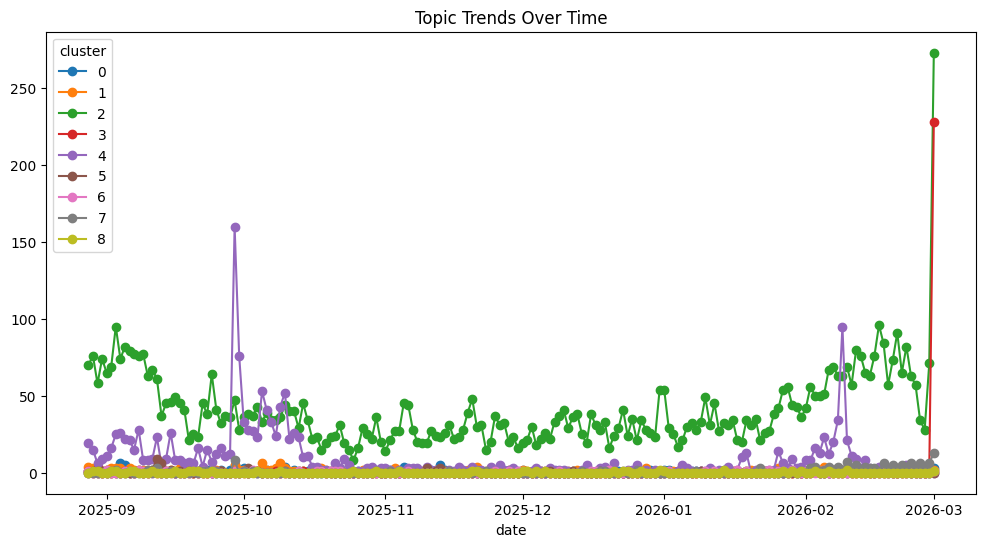

In [14]:
trend.plot(figsize=(12, 6), marker='o')
plt.title('Topic Trends Over Time')
plt.show()
df.to_csv('final_clustered_results.csv', index=False)

In [15]:
df.to_csv('clustered_output.csv', index=False)
print('Project Export Complete.')

Project Export Complete.
